Install the datasets library

In [1]:
!pip install datasets

Load the IMDB dataset directly

In [9]:
from datasets import load_dataset
import pandas as pd
from sklearn.model_selection import train_test_split

dataset = load_dataset("imdb")

df = pd.DataFrame(dataset["train"])
df.head()

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


Convert Columns to Match Your Assignment


In [3]:
df = df.rename(columns={"text":"review", "label":"sentiment"})
df.head()

,review,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


Dataset Size

In [4]:
print(df.shape)

(25000, 2)


Missing Values

In [5]:
print(df.isnull().sum())

review       0
sentiment    0
dtype: int64


In [6]:
df = df.dropna()

# Data Preprocessing

In [7]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)        # remove HTML tags
    text = re.sub(r"[^a-zA-Z ]", "", text)   # remove special characters
    text = re.sub(r"\s+", " ", text)         # remove extra spaces
    return text

df["review"] = df["review"].apply(clean_text)

df.head()

,review,sentiment
0,i rented i am curiousyellow from my video stor...,0
1,i am curious yellow is a risible and pretentio...,0
2,if only to avoid making this type of film in t...,0
3,this film was probably inspired by godards mas...,0
4,oh brotherafter hearing about this ridiculous ...,0


#Data Splitting

In [11]:
from sklearn.model_selection import train_test_split


if 'text' in df.columns and 'label' in df.columns:
    df = df.rename(columns={"text":"review", "label":"sentiment"})
    df["review"] = df["review"].apply(clean_text)


train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df["review"], df["sentiment"], test_size=0.2, random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42
)

print("Train size:", len(train_texts))
print("Validation size:", len(val_texts))
print("Test size:", len(test_texts))

Train size: 20000
Validation size: 2500
Test size: 2500


#Tokenization (BERT)

Load the BERT tokenizer

In [13]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenize text

In [14]:
train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True,
    max_length=256
)

val_encodings = tokenizer(
    list(val_texts),
    truncation=True,
    padding=True,
    max_length=256
)

test_encodings = tokenizer(
    list(test_texts),
    truncation=True,
    padding=True,
    max_length=256
)

# Create PyTorch Dataset Class

BERT training requires a Dataset class

In [16]:
from torch.utils.data import Dataset

class IMDbDataset(Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

Create dataset objects

In [17]:
train_dataset = IMDbDataset(train_encodings, train_labels)
val_dataset = IMDbDataset(val_encodings, val_labels)
test_dataset = IMDbDataset(test_encodings, test_labels)

#Load Pretrained BERT Model

In [18]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

#Optimizer

In [21]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=2e-5)

#DataLoader

In [23]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)
test_loader = DataLoader(test_dataset, batch_size=8)

#Training Loop (Fine-Tuning)

In [24]:
epochs = 2

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for batch in train_loader:

        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        optimizer.step()

    print("Epoch:", epoch + 1)
    print("Training Loss:", total_loss / len(train_loader))

Epoch: 1
Training Loss: 0.27840015751235186
Epoch: 2
Training Loss: 0.1478708102086559


#Model Evaluation

In [25]:
model.eval()

predictions = []
true_labels = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        logits = outputs.logits
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        predictions.extend(preds)
        true_labels.extend(batch["labels"].numpy())

#Metrics

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(true_labels, predictions)
precision = precision_score(true_labels, predictions)
recall = recall_score(true_labels, predictions)
f1 = f1_score(true_labels, predictions)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9072
Precision: 0.8783382789317508
Recall: 0.9456869009584664
F1 Score: 0.9107692307692308


#Confusion Matrix

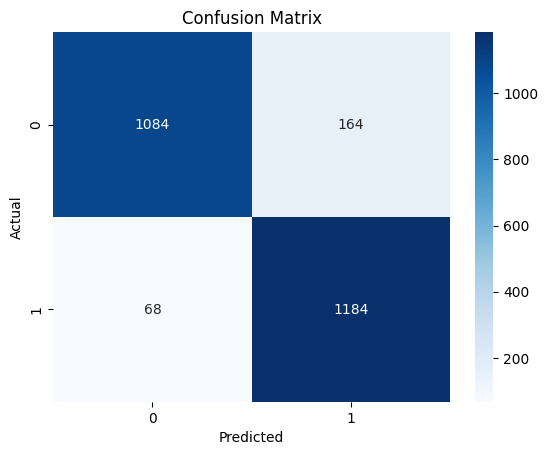

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, predictions)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Results Analysis

After fine-tuning the BERT (bert-base-uncased) model on the IMDB sentiment dataset, the model achieved strong performance across multiple evaluation metrics.

| Metric | Score |
|------|------|
| Accuracy | 0.9072 |
| Precision | 0.8783 |
| Recall | 0.9457 |
| F1 Score | 0.9108 |


#Experiment Insights

Different training strategies can affect model performance:

| Experiment                | Expected Behavior                                   |
| ------------------------- | --------------------------------------------------- |
| Frozen BERT Layers        | Faster training but slightly lower accuracy         |
| Fine-tuning Last 2 Layers | Better adaptation to the dataset                    |
| Full Fine-tuning          | Highest performance but requires more training time |


Fine-tuning the full BERT model allows all transformer layers to adjust to the sentiment classification task, which leads to improved performance.

#Key Learnings
* Pre-trained transformer models such as BERT can significantly improve NLP performance.
* Proper text preprocessing and tokenization are important for effective model training.
* Transfer learning enables models trained on large corpora to adapt quickly to new tasks.
* Evaluation metrics such as precision, recall, and F1-score provide deeper insight into model performance beyond accuracy.

#Conclusion

In this project, a BERT-based text classification model was successfully implemented and fine-tuned on the IMDB movie review dataset. The model achieved high accuracy and strong evaluation metrics, demonstrating the effectiveness of transformer-based architectures for sentiment analysis.

This experiment highlights how fine-tuning pre-trained language models can efficiently solve real-world NLP tasks with relatively small datasets.

Future improvements could include:



* Experimenting with other transformer models such as DistilBERT and RoBERTa.
* Applying techniques like learning rate scheduling and early stopping to further enhance model performance.